<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day3_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


### 2 & 3. Preprocess and Build Fully Connected (Dense) Network
We flatten the 28x28 images into a 784-dimensional vector and normalize them.

In [3]:
# Preprocessing for Dense model
# Assurez-vous d'avoir exécuté la première cellule de chargement des données avant celle-ci.
x_train_dense = x_train.reshape(60000, 784).astype("float32") / 255
x_test_dense = x_test.reshape(10000, 784).astype("float32") / 255

# One-hot encode labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

# Build Dense Model with the new Input layer syntax
model_dense = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Fully Connected Model...")
model_dense.fit(x_train_dense, y_train_cat, epochs=5, batch_size=128, verbose=1)

dense_loss, dense_acc = model_dense.evaluate(x_test_dense, y_test_cat, verbose=0)
print(f"Dense Model Accuracy: {dense_acc:.4f}")

Training Fully Connected Model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9251 - loss: 0.2666
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9682 - loss: 0.1088
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0703
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9850 - loss: 0.0508
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0365
Dense Model Accuracy: 0.9786


### 4 & 5. Preprocess and Build Convolutional Neural Network (CNN)
CNNs expect the data to have a channel dimension (28, 28, 1).

In [3]:
# Preprocessing for CNN
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

# Build CNN Model with the new Input layer syntax
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training CNN Model...")
model_cnn.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=128, verbose=1)

cnn_loss, cnn_acc = model_cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"CNN Model Accuracy: {cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9426 - loss: 0.2003
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9831 - loss: 0.0549
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9881 - loss: 0.0387
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9907 - loss: 0.0291
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9925 - loss: 0.0238
CNN Model Accuracy: 0.9897


### 6. Compare the performance
Now we visualize the test accuracy of both models to see the difference clearly.

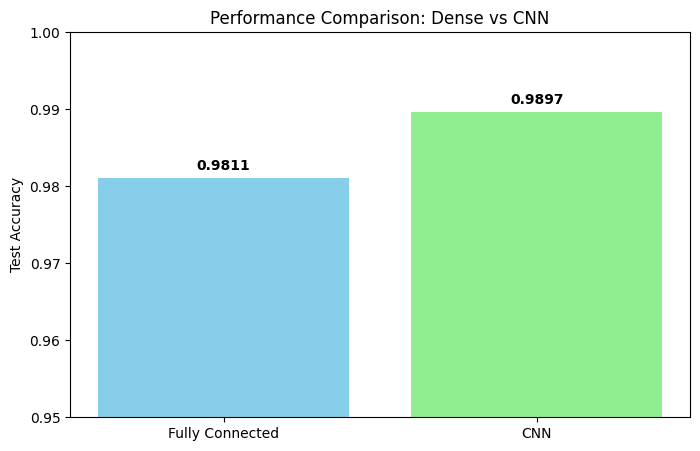

Difference in accuracy: 0.86%


In [4]:
import matplotlib.pyplot as plt

models = ['Fully Connected', 'CNN']
accuracies = [dense_acc, cnn_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0.95, 1.0) # Zoom in to see the difference
plt.ylabel('Test Accuracy')
plt.title('Performance Comparison: Dense vs CNN')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

print(f"Difference in accuracy: {(cnn_acc - dense_acc)*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


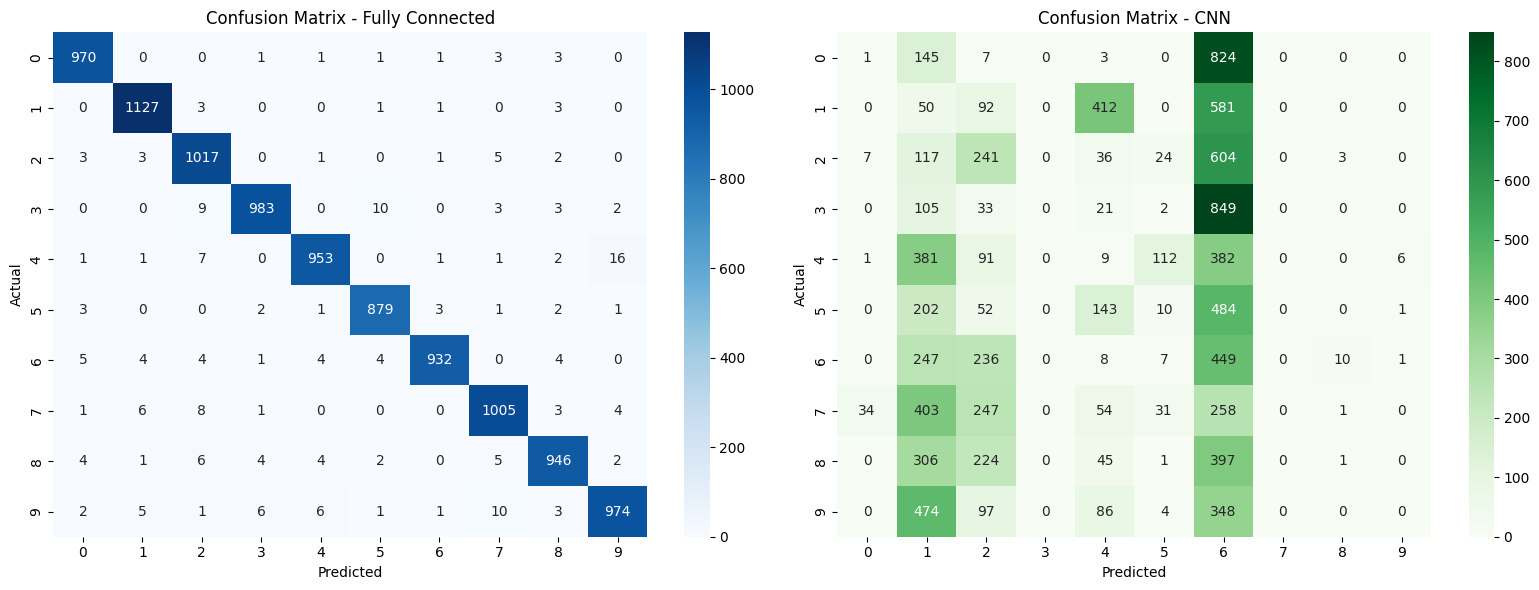

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_dense = np.argmax(model_dense.predict(x_test_dense), axis=1)
y_pred_cnn = np.argmax(model_cnn.predict(x_test_cnn), axis=1)

# Compute confusion matrices
cm_dense = confusion_matrix(y_test, y_pred_dense)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Fully Connected')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - CNN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Visualisation des erreurs du CNN
Identifions les indices où les prédictions ne correspondent pas aux étiquettes réelles.

Entraînement du modèle CNN en cours (5 époques)...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9407 - loss: 0.2028
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9832 - loss: 0.0555
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9880 - loss: 0.0389
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9912 - loss: 0.0292
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9925 - loss: 0.0245
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


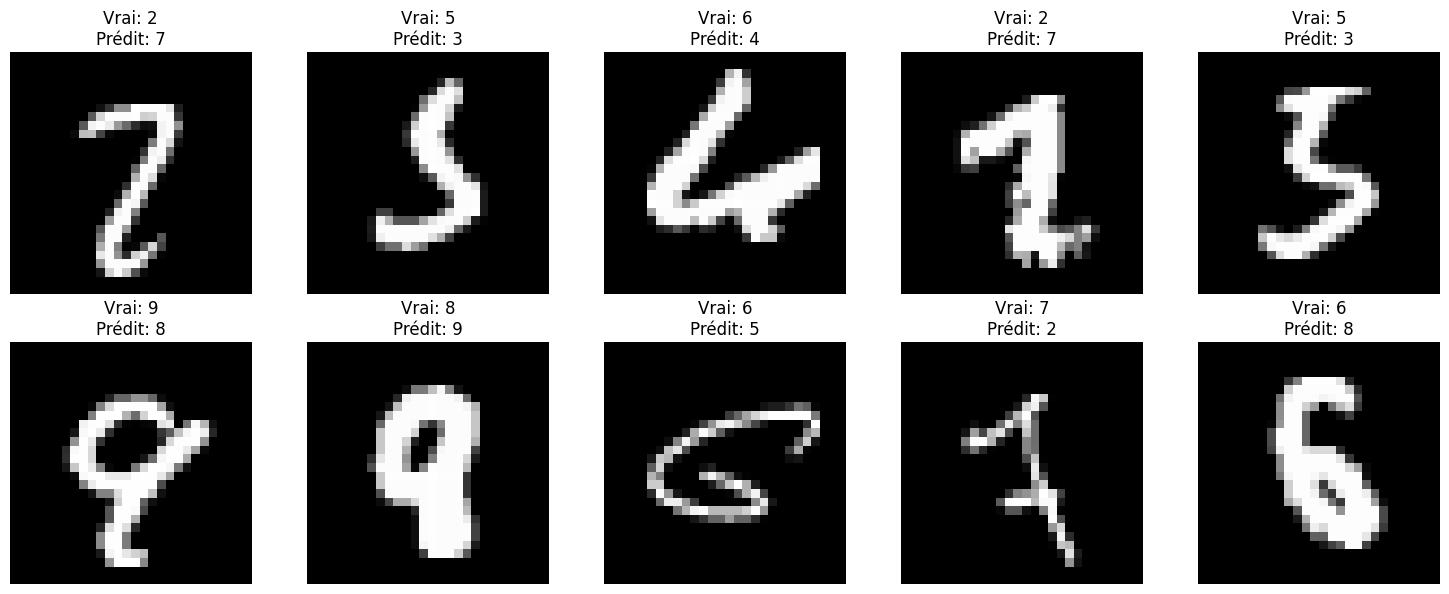

Nombre total d'erreurs : 95 sur 10,000
Précision réelle : 99.05%


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# 1. Préparation des données
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

# 2. Entraînement complet du modèle CNN pour garantir la précision
print("Entraînement du modèle CNN en cours (5 époques)...")
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=128, verbose=1)

# 3. Calcul des prédictions
predictions = model_cnn.predict(x_test_cnn)
y_pred_cnn = np.argmax(predictions, axis=1)

# 4. Analyse des erreurs
misclassified_indices = np.where(y_pred_cnn != y_test)[0]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Vrai: {y_test[idx]}\nPrédit: {y_pred_cnn[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Nombre total d'erreurs : {len(misclassified_indices)} sur 10,000")
print(f"Précision réelle : {(1 - len(misclassified_indices)/10000)*100:.2f}%")

### Conclusion
The CNN model is more effective for image classification because it preserves the spatial structure of the pixels through convolution layers, whereas the Fully Connected model loses this information by flattening the image into a single vector.